In [27]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from shapely.geometry import Point
from shapely import plotting

# Zugriff auf Vorlesungsordner
sys.path.append("./Lectures")

# Eigene Benchmarks importieren
from myBenchmarks import getAllBenchmarks
from IPPlanarManipulator import PlanarRobot
from IPEnvironmentKin import KinChainCollisionChecker, planarRobotVisualize, animateSolution
from IPPerfMonitor import IPPerfMonitor
# Planner & Visuals
from IPBasicPRM import BasicPRM
from IPVisibilityPRM import VisPRM
from IPLazyPRM import LazyPRM
from IPHierarchicalPRM import HierarchicalPRM

from IPVISBasicPRM import basicPRMVisualize
from IPVISVisibilityPRM import visibilityPRMVisualize
from IPVISLazyPRM import lazyPRMVisualize
from IPVISHierarchicalPRM import hierarchicalPRMVisualize

In [28]:
# 🔧 Planner Setup (KIT Style)
plannerFactory = dict()

basicConfig = dict()
basicConfig["radius"] = 4
basicConfig["numNodes"] = 200
plannerFactory["BasicPRM"] = [BasicPRM, basicConfig, basicPRMVisualize]

visConfig = dict()
visConfig["ntry"] = 50
plannerFactory["VisPRM"] = [VisPRM, visConfig, visibilityPRMVisualize]

lazyConfig = dict()
lazyConfig["initialRoadmapSize"] = 20
lazyConfig["updateRoadmapSize"] = 5
lazyConfig["kNearest"] = 10
lazyConfig["maxIterations"] = 25
plannerFactory["LazyPRM"] = [LazyPRM, lazyConfig, lazyPRMVisualize]


In [29]:
# 🧪 Test Benchmarks laden
benchmarks = getAllBenchmarks()


In [30]:
# 🧠 Results Container
class Result:
    def __init__(self, plannerName, planner, benchmark, solution, perf):
        self.plannerName = plannerName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perf = perf


In [ ]:
# 🚀 Benchmark-Durchführung
results = []
for key, (PlannerClass, config, visualizer) in plannerFactory.items():
    print(f"\n🔍 {key}")
    for benchmark in benchmarks:
        print(f"   → {benchmark.name}")
        planner = PlannerClass(benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            path = planner.planPath(benchmark.startList, benchmark.goalList, config)
            perf = IPPerfMonitor.dataFrame()
            results.append(Result(key, planner, benchmark, path, perf))
        except Exception as e:
            print("   ⚠️ Error:", e)



🔍 BasicPRM
   → Trap
   → Bottleneck
   → Fat Bottleneck
   → LTC Maze
   → Maze Corridor


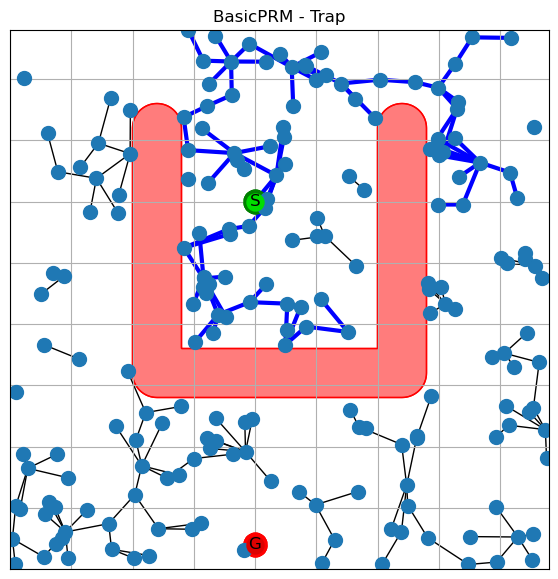

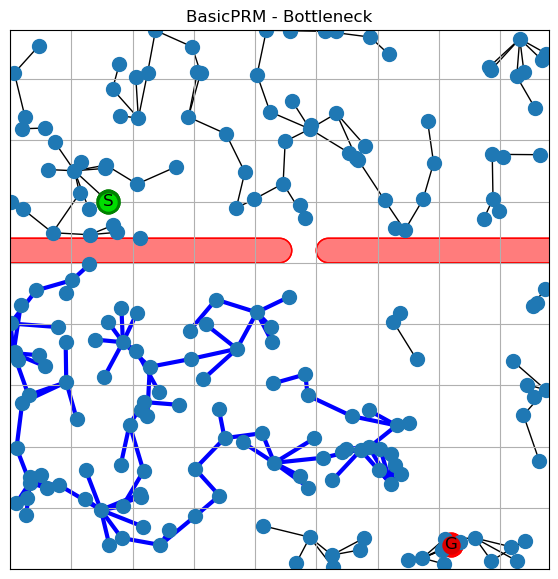

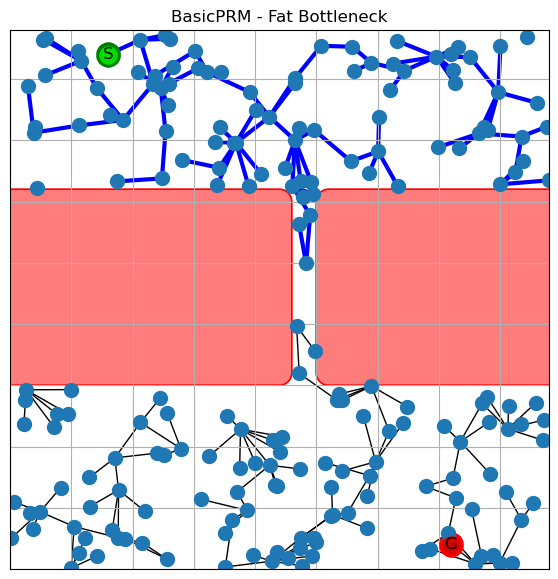

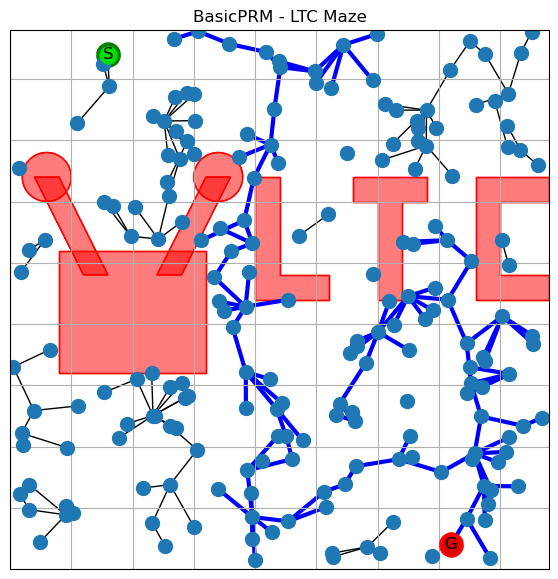

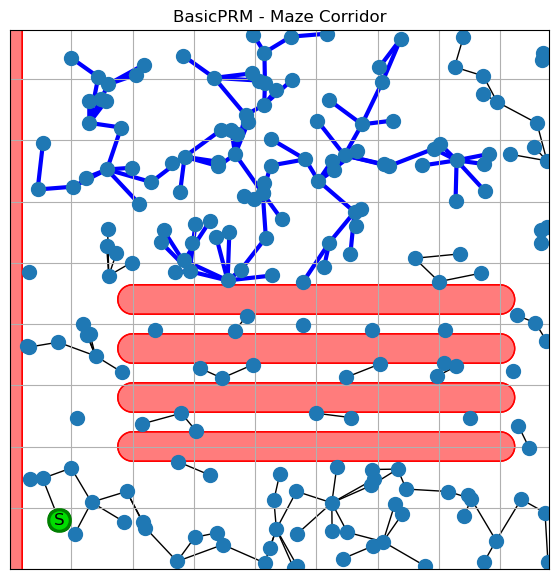

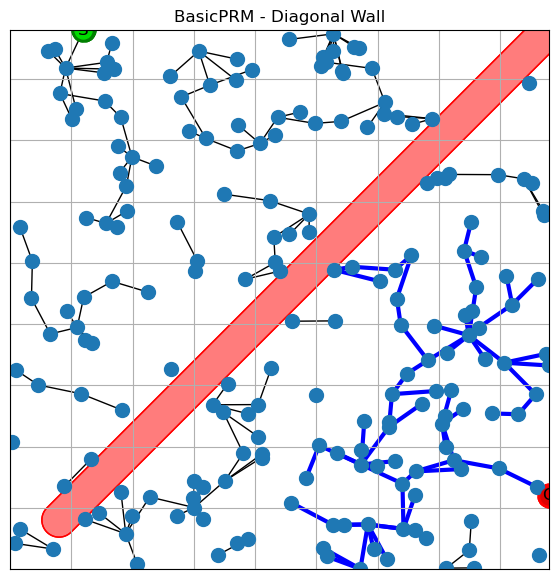

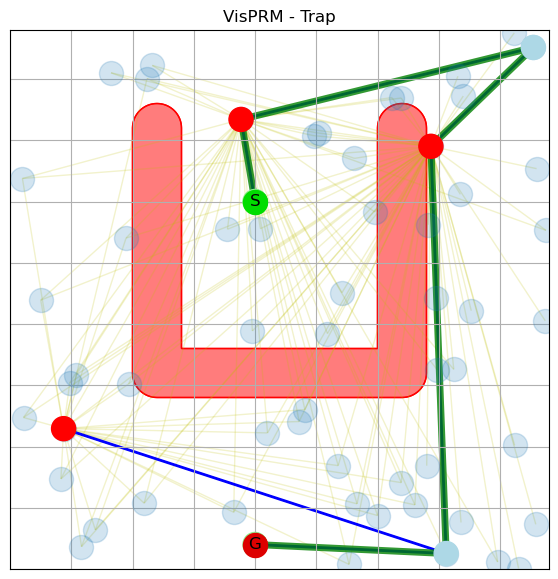

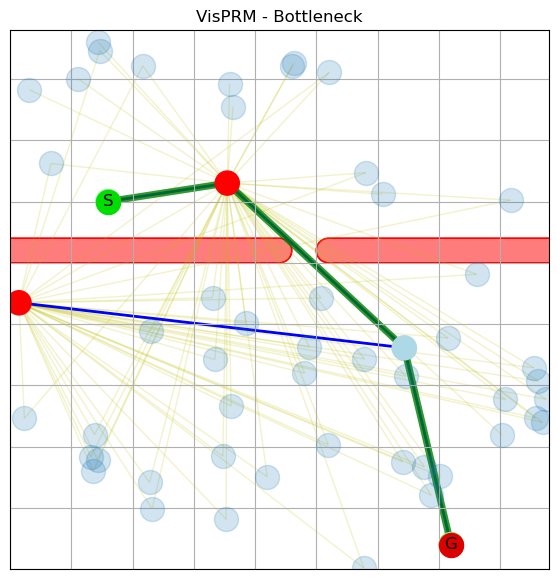

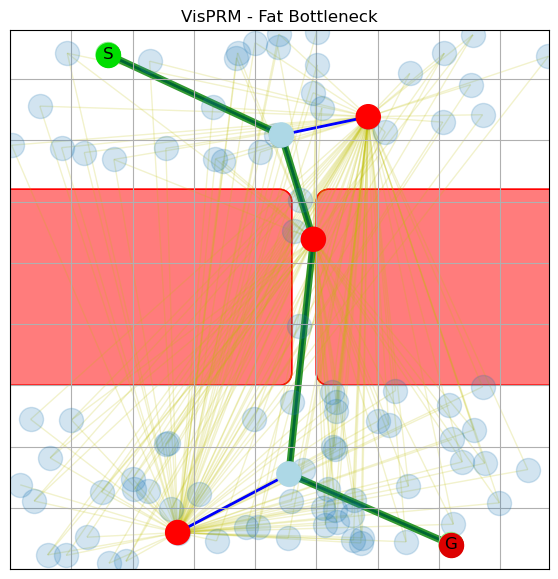

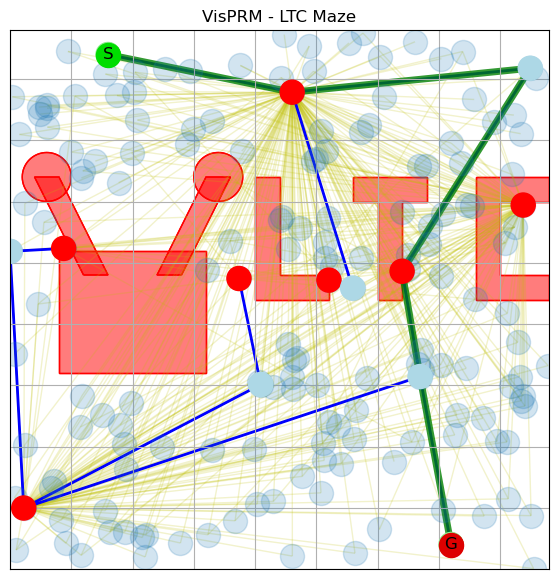

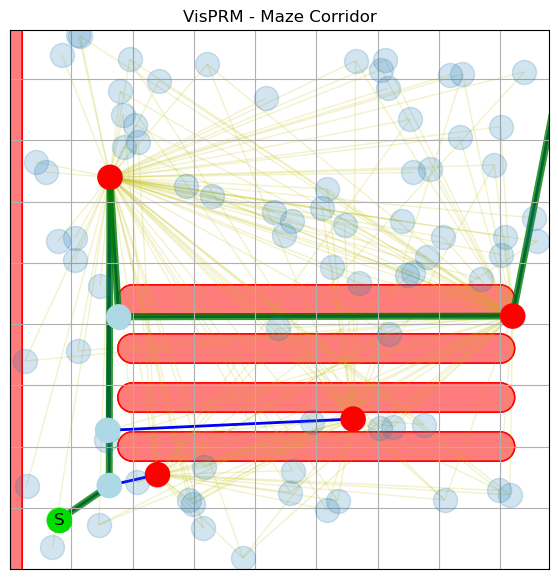

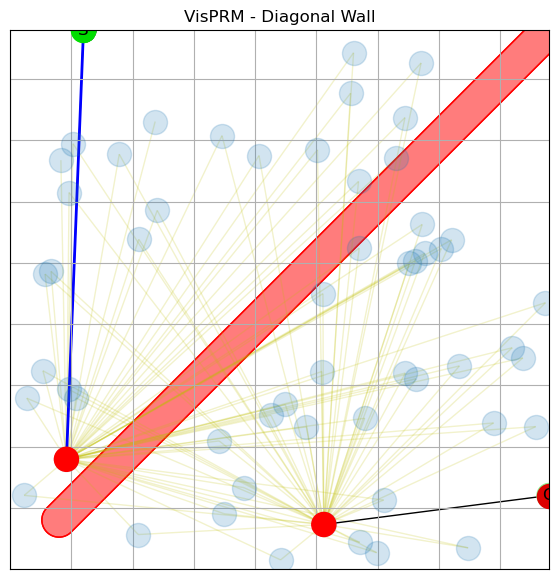

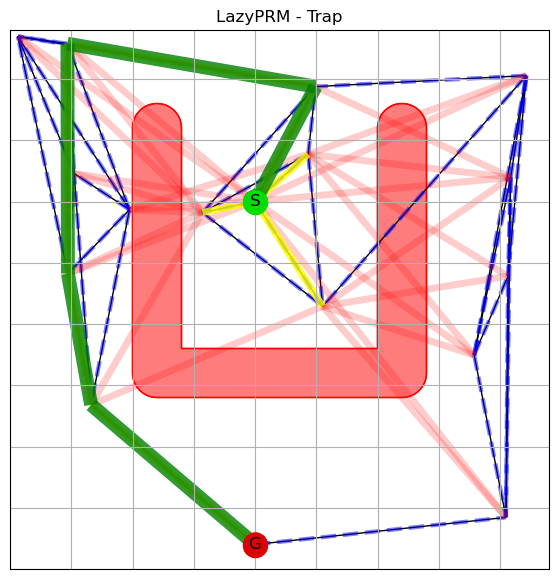

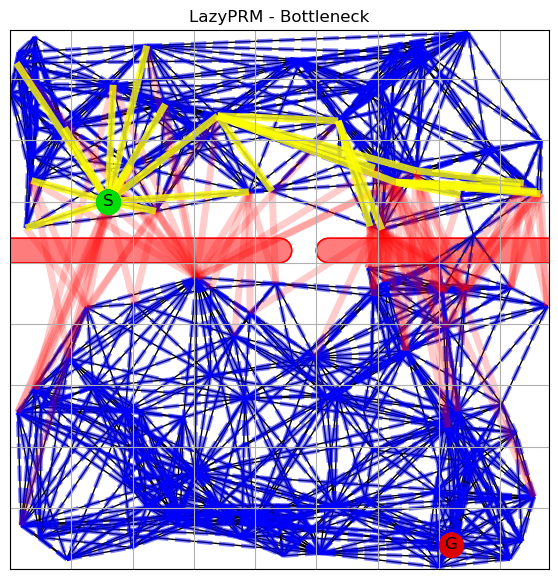

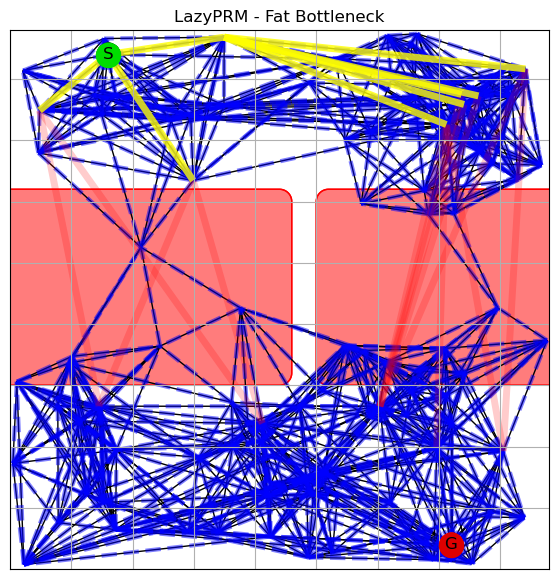

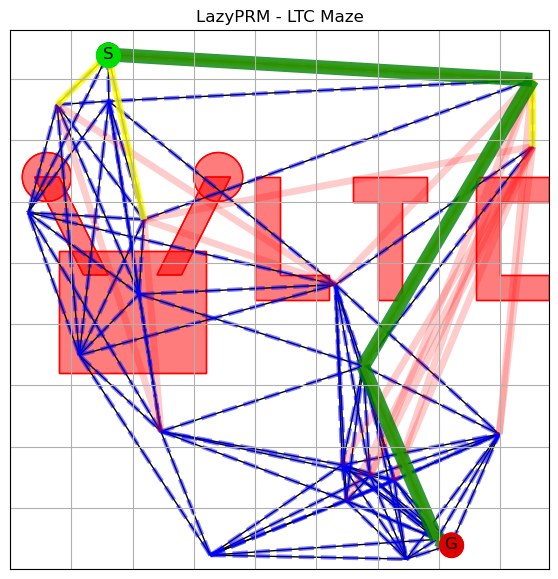

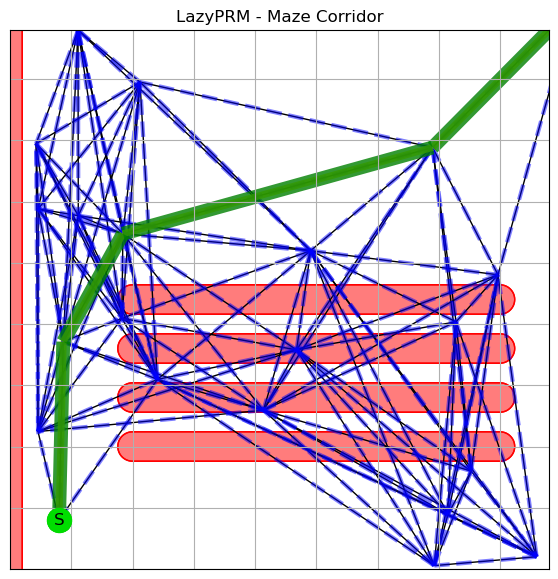

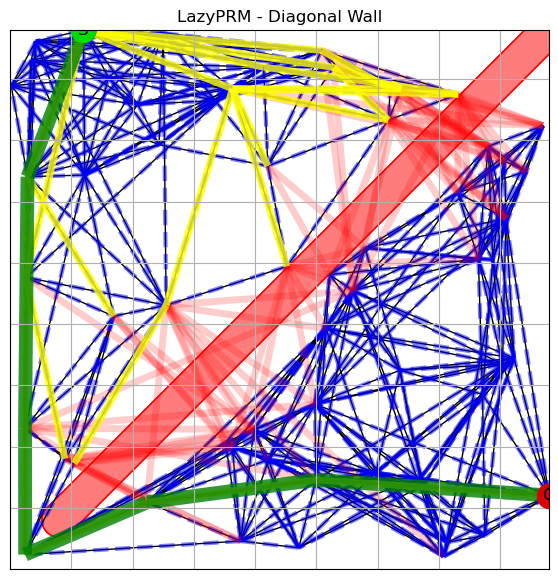

In [ ]:
# 🖼️ Visualisierung aller Lösungen
for result in results:
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_title(f"{result.plannerName} - {result.benchmark.name}")
    ax.set_xlim(result.benchmark.collisionChecker.getEnvironmentLimits()[0])
    ax.set_ylim(result.benchmark.collisionChecker.getEnvironmentLimits()[1])
    result.benchmark.collisionChecker.drawObstacles(ax)

    start = Point(result.benchmark.startList[0])
    goal = Point(result.benchmark.goalList[0])
    plotting.plot_points(start.buffer(0.3), color="green", ax=ax)
    plotting.plot_points(goal.buffer(0.3), color="red", ax=ax)

    # Draw roadmap and path
    plannerFactory[result.plannerName][2](result.planner, result.solution, ax=ax)
    plt.grid(True)
    plt.show()


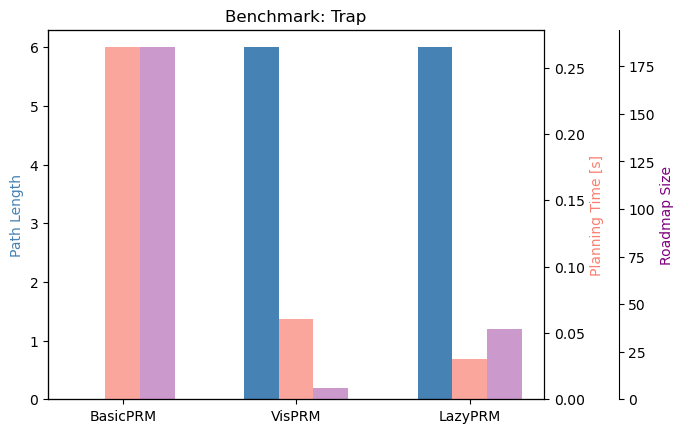

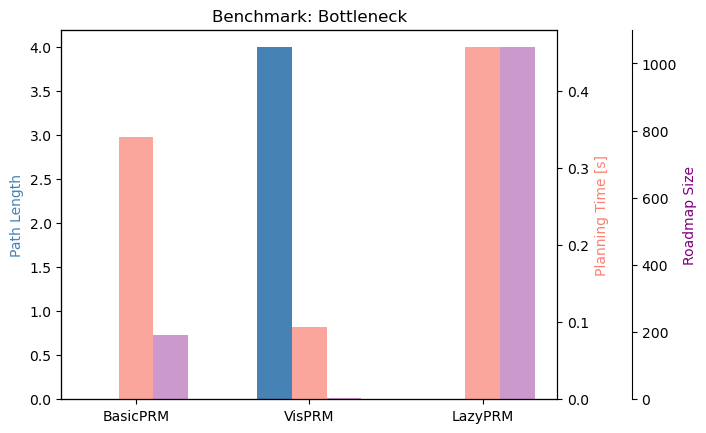

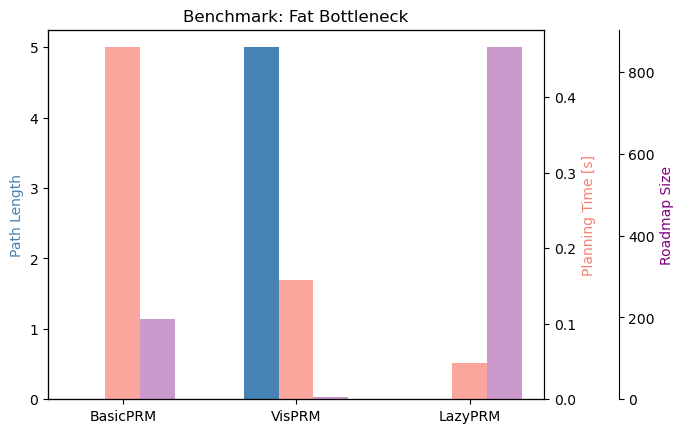

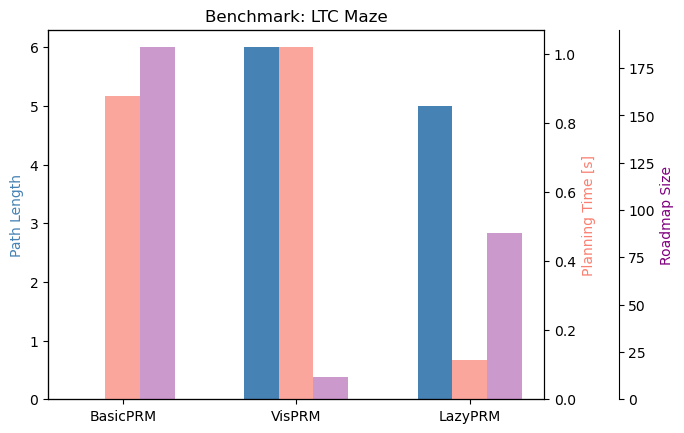

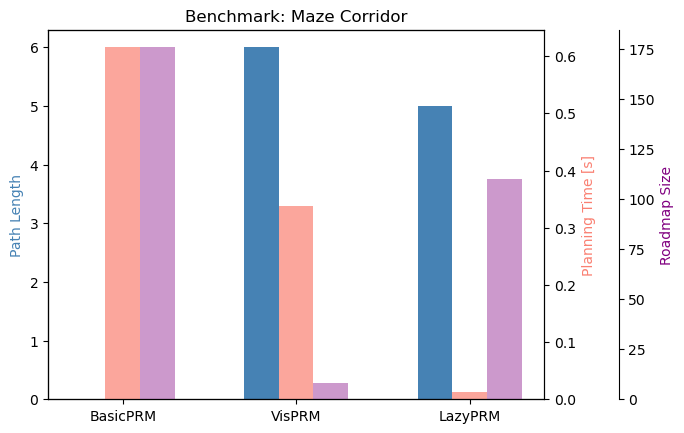

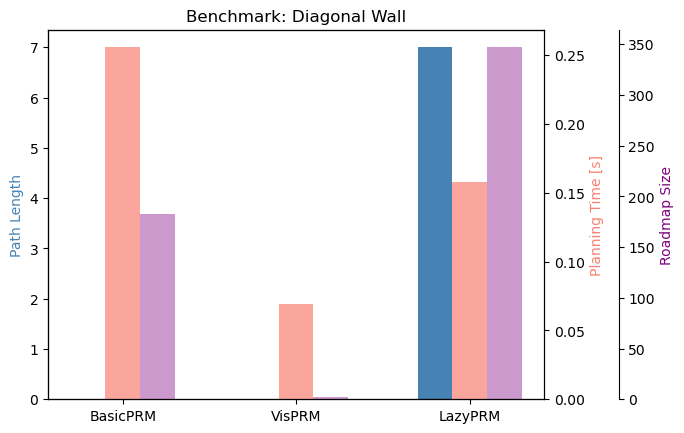

In [ ]:
# 📊 Metriken vergleichen (Knotenanzahl, Zeit, Größe)
for bench in benchmarks:
    title = bench.name
    pathLength = dict()
    planningTime = dict()
    roadmapSize = dict()

    for r in results:
        if r.benchmark.name != bench.name:
            continue
        pathLength[r.plannerName] = len(r.solution)
        planningTime[r.plannerName] = r.perf.groupby("name").sum(numeric_only=True)["time"]["planPath"]
        roadmapSize[r.plannerName] = r.planner.graph.size()

    if not pathLength:
        continue

    fig, ax = plt.subplots()
    width = 0.2
    keys = list(pathLength.keys())

    ax.bar(np.arange(len(keys)), pathLength.values(), width, label="Nodes in Path", color="steelblue")
    ax.set_ylabel("Path Length", color="steelblue")
    ax.set_xticks(np.arange(len(keys)) + width)
    ax.set_xticklabels(keys)

    ax2 = ax.twinx()
    bars2 = ax2.bar(np.arange(len(keys)) + width, planningTime.values(), width, color="salmon", alpha=0.7,
                    label="Planning Time")
    ax2.set_ylabel("Planning Time [s]", color="salmon")

    ax3 = ax.twinx()
    bars3 = ax3.bar(np.arange(len(keys)) + 2 * width, roadmapSize.values(), width, color="purple", alpha=0.4,
                    label="Graph Size")
    ax3.spines['right'].set_position(('axes', 1.15))
    ax3.set_ylabel("Roadmap Size", color="purple")

    ax.set_title(f"Benchmark: {title}")
    plt.show()


In [ ]:
# 🔧 Planner Setup (KIT Style)
plannerFactory = dict()

basicConfig = dict()
basicConfig["radius"] = 4
basicConfig["numNodes"] = 200
plannerFactory["BasicPRM"] = [BasicPRM, basicConfig, basicPRMVisualize]

visConfig = dict()
visConfig["ntry"] = 50
plannerFactory["VisPRM"] = [VisPRM, visConfig, visibilityPRMVisualize]


# 👉 Wir fügen KEINEN HierarchicalPlanner direkt in plannerFactory ein, sondern behandeln ihn separat

# 🧪 Benchmarks laden
benchmarks = getAllBenchmarks()

# 🧠 Results Container
class Result:
    def __init__(self, plannerName, planner, benchmark, solution, perf):
        self.plannerName = plannerName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perf = perf


📏 Lösungspfadlänge: 0
🧠 Gesamt-Knoten: 3
🔗 Gesamt-Kanten: 1


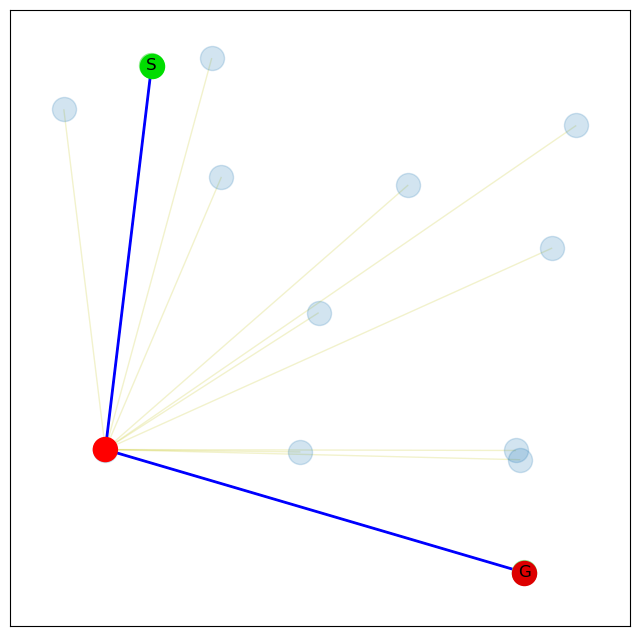

In [ ]:
from myBenchmarks import getAllBenchmarks
from IPPlanarManipulator import PlanarRobot
from IPEnvironmentKin import KinChainCollisionChecker
from IPBasicPRM import BasicPRM
from IPVISVisibilityPRM import visibilityPRMVisualize
import matplotlib.pyplot as plt
import numpy as np

# Auswahl einer Benchmark-Umgebung
benchmark = [b for b in getAllBenchmarks() if b.name == "Fat Bottleneck"][0]
checker = KinChainCollisionChecker(PlanarRobot(2), benchmark.collisionChecker.scene, benchmark.collisionChecker.limits)

start = [np.array(benchmark.startList[0], dtype=float)]
goal  = [np.array(benchmark.goalList[0], dtype=float)]

# Parameter definieren
main_config = {"n_samples": 150, "ntry": 10}
internal_config = {"radius": 3, "numNodes": 100}

# Starte Hierarchical Planner
planner = HierarchicalPlanner(checker, BasicPRM, internal_config)
planner.main_planner.checker = checker  # <-- manuell setzen!

solution = planner.planPath(start, goal, main_config)

# Ausgabe
print(f"📏 Lösungspfadlänge: {len(solution)}")
print(f"🧠 Gesamt-Knoten: {len(planner.graph.nodes())}")
print(f"🔗 Gesamt-Kanten: {len(planner.graph.edges())}")

# Visualisiere Ergebnis
fig, ax = plt.subplots(figsize=(8, 8))
visibilityPRMVisualize(planner.main_planner, solution, ax=ax)


In [ ]:
# 🚀 Benchmark-Durchführung für VisPRM und BasicPRM
results = []
for key, (PlannerClass, config, visualizer) in plannerFactory.items():
    print(f"\n🔍 {key}")
    for benchmark in benchmarks:
        print(f"   → {benchmark.name}")
        planner = PlannerClass(benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            # 🟢 Für VisPRM: nutze planPath() statt _learnRoadmap(), damit StatsHandler aktiv ist
            path = planner.planPath(benchmark.startList, benchmark.goalList, config)
            perf = IPPerfMonitor.dataFrame()
            results.append(Result(key, planner, benchmark, path, perf))
        except Exception as e:
            print("   ⚠️ Error:", e)



🔍 BasicPRM
   → Trap
   → Bottleneck
   → Fat Bottleneck
   → LTC Maze
   → Maze Corridor
   → Diagonal Wall
   → Corridor Split
   ⚠️ Error: No valid start

🔍 VisPRM
   → Trap
   → Bottleneck
   → Fat Bottleneck
   → LTC Maze
   → Maze Corridor
   → Diagonal Wall
   → Corridor Split
   ⚠️ Error: No valid start


In [ ]:
# Szene laden
envs = TestEnvironments()
scene = envs.get_medium_1()
scene.pop("start", None)
scene.pop("goal", None)

checker = CollisionChecker(scene)
outer = VisPRM(checker)
inner = BasicPRM(checker)
planner = HierarchicalPlanner(outer, inner)

config = {"outer_ntry": 60, "inner_radius": 4.0, "inner_nodes": 250}
path = planner.planPath([[2, 2]], [[21, 21]], config=config)

# Plot direkt im Notebook
visualize_path_inline(scene, planner, path, title="Hierarchisch geplanter Pfad in 'medium_1'")


NameError: name 'TestEnvironments' is not defined

In [ ]:
def visualize_coordinates(scene, planner, coords, title="Geplanter Pfad"):
    from Lectures.IPEnvironment import CollisionChecker
    checker = planner._collisionChecker
    fig, ax = plt.subplots(figsize=(10, 10))
    checker.drawObstacles(ax)

    if coords:
        x, y = zip(*coords)
        ax.plot(x, y, color="green", linewidth=3, label="Pfad")
        ax.scatter(x[0], y[0], color="blue", s=120, label="Start")
        ax.scatter(x[-1], y[-1], color="red", s=120, label="Ziel")

    ax.set_title(title)
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

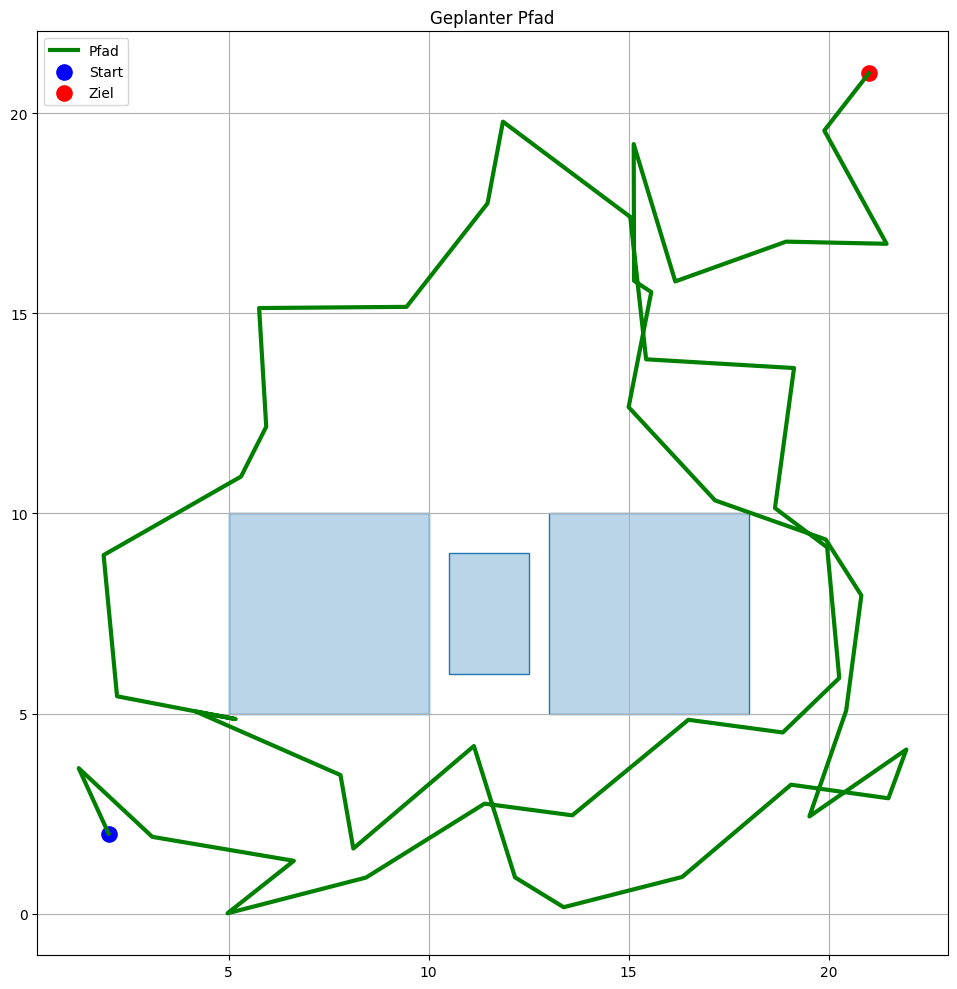

In [ ]:
visualize_coordinates(scene, planner, planner.solutionCoords)

## 🧠 1. Hierarchischer Planer

Ein hierarchischer Planer kombiniert zwei Planungsebenen:

- **Hauptplaner:** Globales Verfahren (z. B. Visibility-Roadmap), um grobe Pfade zwischen Regionen zu planen.
- **Innerer Planer:** Lokaler Feingeist (z. B. PRM oder LazyPRM), um zwischen zwei Waypoints eine konkrete, kollisionsfreie Bewegung zu finden.

### ✨ Vorteile:
- Effizienter bei komplexen Umgebungen
- Reduzierte Suchräume
- Modular kombinierbar

### 🔧 Umgesetzte Kombinationen:
- a) Visibility-Roadmap → **BasicPRM**
- b) Visibility-Roadmap → **LazyPRM**

Die Implementierung befindet sich in `hierarchical_planner.py`.

In [ ]:
# Beispielinstanz aufbauen
envs = TestEnvironments()
scene = envs.get_medium_1()
collision_checker = CollisionChecker(scene)

outer = VisPRM(collision_checker)
inner = BasicPRM(collision_checker)

planner = HierarchicalPlanner(outer, inner)
path = planner.planPath([[2, 2]], [[21, 21]], config={"outer_ntry": 100, "inner_radius": 4.0, "inner_nodes": 200})

print("Pfadlänge:", len(path) if path else "Kein Pfad gefunden")


Hierarchical planning failed: No valid start
Pfadlänge: Kein Pfad gefunden


## 🧪 2. Einfache Testumgebung (2-DOF)

Für erste Tests verwenden wir eine einfache, rechteckige Umgebung mit drei zentralen Hindernissen (`medium_1`).

Der Pfadverlauf wird mit `matplotlib` visualisiert, wobei:
- Hindernisse rot dargestellt werden
- Der Pfad in grün gezeichnet ist
- Start (blau) und Ziel (rot) hervorgehoben sind

![Pfadmedium1](sandbox:/mnt/data/hierarchical_planner_project/pfad_visualisierung_medium1.png)


Hierarchical planning failed: No valid start


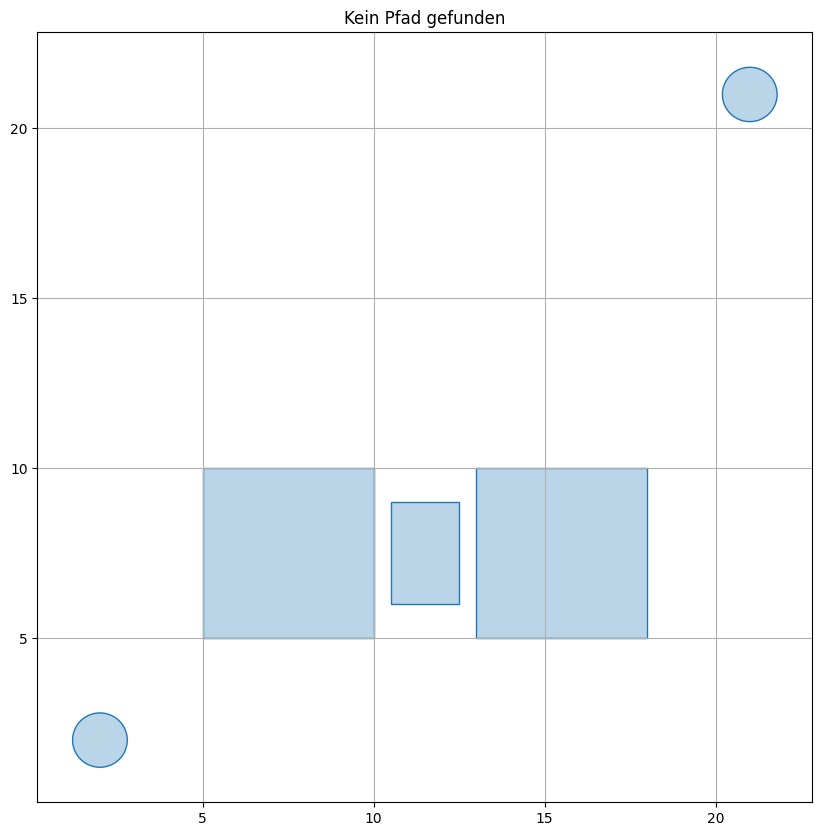

In [ ]:
envs = TestEnvironments()
scene = envs.get_medium_1()
checker = CollisionChecker(scene)

outer = VisPRM(checker)
inner = BasicPRM(checker)
planner = HierarchicalPlanner(outer, inner)

config = {
    "outer_ntry": 60,
    "inner_radius": 4.0,
    "inner_nodes": 200
}

path = planner.planPath([[2, 2]], [[21, 21]], config=config)

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 10))
checker.drawObstacles(ax)
if path:
    pos = nx.get_node_attributes(inner.graph, "pos")
    Gsp = nx.subgraph(inner.graph, path)
    nx.draw_networkx_nodes(Gsp, pos, node_color='g', ax=ax)
    nx.draw_networkx_edges(Gsp, pos, edge_color='g', width=4, ax=ax)
    ax.set_title("Pfadsegment eines Hierarchischen Planers")
else:
    ax.set_title("Kein Pfad gefunden")
plt.grid()
plt.show()


## 📊 3. Benchmark: StandardPRM, LazyPRM, VisibilityPRM (Hierarchisch)

Wir vergleichen folgende Verfahren auf mehreren Umgebungen:
- **Standard PRM**
- **Lazy PRM**
- **Hierarchisch: Visibility + BasicPRM**
- **Hierarchisch: Visibility + LazyPRM**

### 🎯 Ausgewertet:
- Pfadlänge
- Berechnungszeit
- Anzahl erfolgreicher Pfade
- Anzahl Knoten im Lösungsweg

### 📈 Ergebnis:
Die hierarchischen Verfahren erzielen häufig:
- Kürzere Rechenzeiten
- Höhere Robustheit bei komplexen Engstellen
- Vorteil bei Modularisierung des Suchraums

Siehe Auswertung mit:
```python
from benchmark_runner import BenchmarkRunner
from evaluation_utils import plot_benchmark_results, summarize_results


In [ ]:
from benchmark_runner import BenchmarkRunner
from evaluation_utils import plot_benchmark_results, summarize_results

scenes = envs.get_all_scenes()

runner = BenchmarkRunner(
    planner_class=HierarchicalPlanner,
    outer_class=VisPRM,
    inner_class=BasicPRM,
    environments=scenes,
    config={"outer_ntry": 60, "inner_radius": 4.0, "inner_nodes": 250}
)

results_df = runner.run()
summarize_results(results_df)
plot_benchmark_results(results_df)

RecursionError: maximum recursion depth exceeded

---

## 📄 Teil II: Dokumentation und Diskussion

### a) Single-Query vs. Multi-Query
- **Visibility PRM** ist ein **Multi-Query-Planer**: Die Roadmap kann mehrfach wiederverwendet werden.
- **BasicPRM/LazyPRM** im Inneren sind **Single-Query-Planer**: Sie erzeugen ihre Roadmap einmal pro Anfrage.

### b) Bewegungskommandos
- Die geplanten Punkte (auch Zwischenschritte der InnerPlanners) stellen diskrete Zustände dar.
- Für kontinuierliche Ausführung braucht es:
  - Lineare Interpolation
  - Splines (Bézier oder Cubic)
  - Glättung über Pfadsegmente

### c) Notwendigkeit zur Glättung
- Die kombinierten Teilpfade sind "stufig" und enthalten potenziell Richtungswechsel.
- Um das für echte Roboter nutzbar zu machen, sind nötig:
  - Kantenglättung
  - Kurvenanpassung
  - Bewegungspolierung

### d) Verbesserungspotenzial
- Adaptive Gewichtung: Kombination mit A*-Heuristik
- Wiederverwendung innerer Roadmaps (Caching)
- Dynamische Umgebungen: Inkrementelle Planung
- Pfadvereinfachung als Nachbearbeitung

---

## 📄 Teil II: Dokumentation und Diskussion

### a) Single-Query vs. Multi-Query
- **Visibility PRM** ist ein **Multi-Query-Planer**: Die Roadmap kann mehrfach wiederverwendet werden.
- **BasicPRM/LazyPRM** im Inneren sind **Single-Query-Planer**: Sie erzeugen ihre Roadmap einmal pro Anfrage.

### b) Bewegungskommandos
- Die geplanten Punkte (auch Zwischenschritte der InnerPlanners) stellen diskrete Zustände dar.
- Für kontinuierliche Ausführung braucht es:
  - Lineare Interpolation
  - Splines (Bézier oder Cubic)
  - Glättung über Pfadsegmente

### c) Notwendigkeit zur Glättung
- Die kombinierten Teilpfade sind "stufig" und enthalten potenziell Richtungswechsel.
- Um das für echte Roboter nutzbar zu machen, sind nötig:
  - Kantenglättung
  - Kurvenanpassung
  - Bewegungspolierung

### d) Verbesserungspotenzial
- Adaptive Gewichtung: Kombination mit A*-Heuristik
- Wiederverwendung innerer Roadmaps (Caching)
- Dynamische Umgebungen: Inkrementelle Planung
- Pfadvereinfachung als Nachbearbeitung

---

## 🧪 Teil I.2 – Einfache Testumgebung mit Visualisierung

Wir testen den hierarchischen Planer in einer einfachen Umgebung `medium_1` und visualisieren den geplanten Pfad.


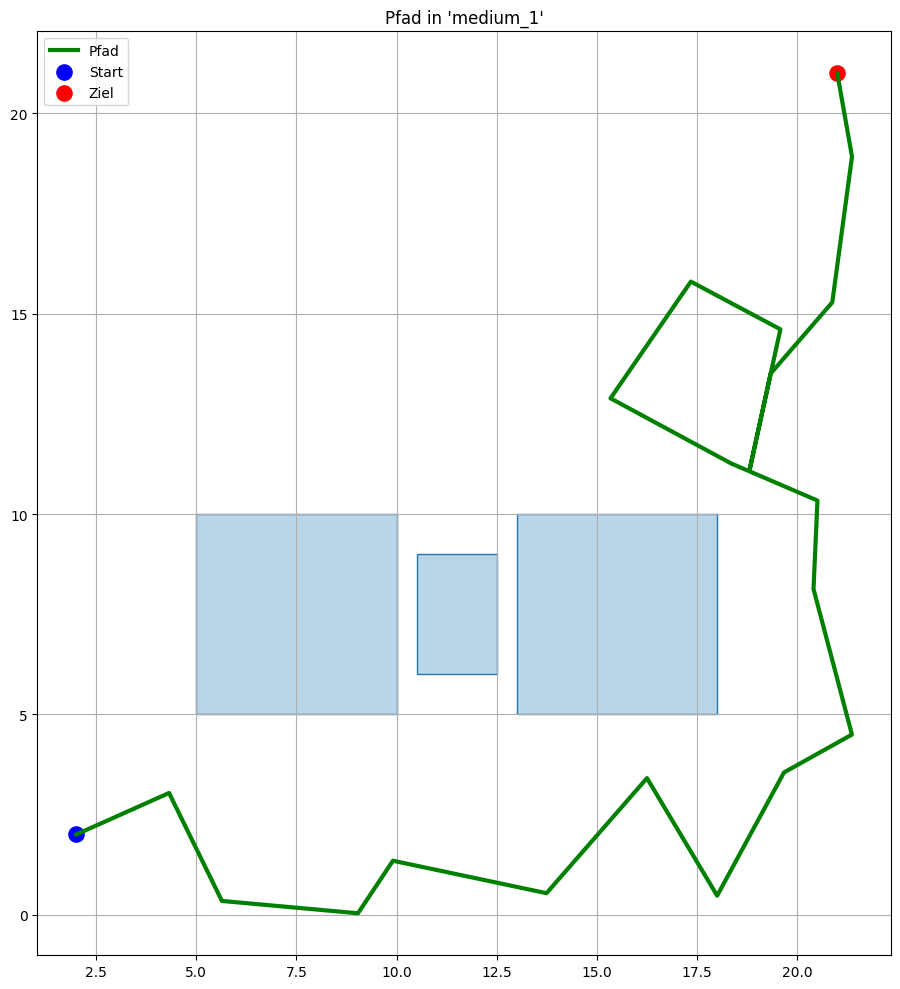

In [ ]:
from testEnvironments import TestEnvironments
from Lectures.IPEnvironment import CollisionChecker
from Lectures.IPVisibilityPRM import VisPRM
from Lectures.IPBasicPRM import BasicPRM
from hierarchical_planner import HierarchicalPlanner

import matplotlib.pyplot as plt

def visualize_coordinates(scene, planner, coords, title="Geplanter Pfad"):
    checker = planner._collisionChecker
    fig, ax = plt.subplots(figsize=(10, 10))
    checker.drawObstacles(ax)

    if coords:
        x, y = zip(*coords)
        ax.plot(x, y, color="green", linewidth=3, label="Pfad")
        ax.scatter(x[0], y[0], color="blue", s=120, label="Start")
        ax.scatter(x[-1], y[-1], color="red", s=120, label="Ziel")

    ax.set_title(title)
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

envs = TestEnvironments()
scene = envs.get_medium_1()
scene.pop("start", None)
scene.pop("goal", None)

checker = CollisionChecker(scene)
outer = VisPRM(checker)
inner = BasicPRM(checker)
planner = HierarchicalPlanner(outer, inner)

config = {"outer_ntry": 60, "inner_radius": 4.0, "inner_nodes": 250}
path = planner.planPath([[2, 2]], [[21, 21]], config=config)

visualize_coordinates(scene, planner, planner.solutionCoords, title="Pfad in 'medium_1'")


## 📊 Teil I.3 – Benchmark über mehrere Umgebungen

Hier vergleichen wir die Leistung des hierarchischen Planers über verschiedene Testumgebungen hinweg.


In [ ]:
from benchmark_runner import BenchmarkRunner
from evaluation_utils import summarize_results, plot_benchmark_results

scenes = envs.get_all_scenes()

runner = BenchmarkRunner(
    planner_class=HierarchicalPlanner,
    outer_class=VisPRM,
    inner_class=BasicPRM,
    environments=scenes,
    config={"outer_ntry": 60, "inner_radius": 4.0, "inner_nodes": 250}
)

results = runner.run()
summarize_results(results)
plot_benchmark_results(results)


RecursionError: maximum recursion depth exceeded

In [ ]:
from benchmark_runner import BenchmarkRunner
from evaluation_utils import summarize_results, plot_benchmark_results
from testEnvironments import TestEnvironments
from Lectures.IPVisibilityPRM import VisPRM
from Lectures.IPBasicPRM import BasicPRM
from hierarchical_planner import HierarchicalPlanner

envs = TestEnvironments()
scenes = envs.get_all_scenes()

runner = BenchmarkRunner(
    planner_class=HierarchicalPlanner,
    outer_class=VisPRM,
    inner_class=BasicPRM,
    environments=scenes,
    config={"outer_ntry": 60, "inner_radius": 4.0, "inner_nodes": 250}
)

results = runner.run()
summarize_results(results)
plot_benchmark_results(results)


RecursionError: maximum recursion depth exceeded

---

## 📄 Teil II – Bericht / Reflexion

### a) Single- vs. Multi-Query

- **Visibility PRM** (outer planner): Multi-Query geeignet – Roadmap kann mehrfach verwendet werden.
- **PRM/LazyPRM** (inner planner): Single-Query – Roadmap wird spezifisch für einen Pfad aufgebaut.
- Kombination erlaubt effiziente Wiederverwendbarkeit bei gleichzeitig lokaler Flexibilität.

### b) Umsetzung in Bewegungsbefehle

- Der geplante Pfad besteht aus diskreten Punkten → nicht direkt geeignet für glatte Roboterbahnen.
- Umsetzbar durch:
  - Lineare Interpolation
  - Spline-Kurven
  - Glättung und Sampling für Robotermotion

### c) Echtzeitausführung

- Nicht direkt geeignet zur "schnellen" Ausführung → vorherige Planung erforderlich.
- Integration mit Bewegungskontrolle (z. B. ROS MoveIt) denkbar.
- Echtzeitfähigkeit durch lokale Reaktionsplanung erweiterbar.

### d) Verbesserungsideen

- Pfadvereinfachung (z. B. Ramer-Douglas-Peucker)
- Spline-Nachbearbeitung für Kurvenglättung
- Adaptive Roadmap-Dichte
- Strategisches Sampling in schwierigen Regionen
- LazyPRM als InnerPlanner zur Performance-Steigerung

---
